In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")


In [2]:

drivers = pd.read_csv("drivers.csv")
trucks = pd.read_csv("trucks.csv")
trailers = pd.read_csv("trailers.csv")
customers = pd.read_csv("customers.csv")
facilities = pd.read_csv("facilities.csv")
routes = pd.read_csv("routes.csv")
loads = pd.read_csv("loads.csv")
trips = pd.read_csv("trips.csv")
fuel_purchases = pd.read_csv("fuel_purchases.csv")
maintenance_records = pd.read_csv("maintenance_records.csv")
delivery_events = pd.read_csv("delivery_events.csv")
safety_incidents = pd.read_csv("safety_incidents.csv")
driver_monthly_metrics = pd.read_csv("driver_monthly_metrics.csv")
truck_utilization_metrics = pd.read_csv("truck_utilization_metrics.csv")


# DESCRIPTIVE ANALYSIS

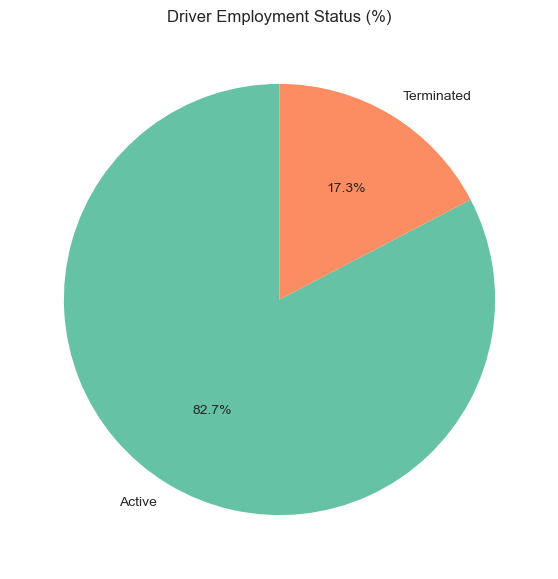

In [3]:
data = drivers["employment_status"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
plt.pie(data, labels=data.index, autopct="%1.1f%%", startangle=90)
plt.title("Driver Employment Status (%)")
plt.show()


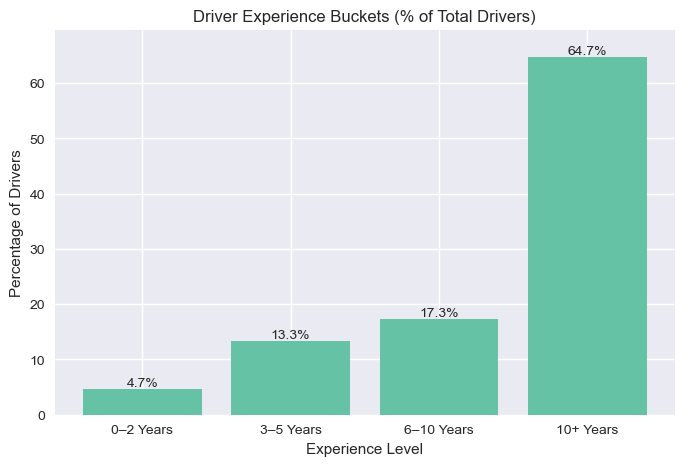

In [4]:
# =========================
# DRIVER EXPERIENCE BUCKETS (%)
# =========================

drivers["exp_bucket"] = pd.cut(
    drivers["years_experience"],
    bins=[0, 2, 5, 10, 30],
    labels=["0–2 Years", "3–5 Years", "6–10 Years", "10+ Years"]
)

data = drivers["exp_bucket"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(8,5))
bars = plt.bar(data.index.astype(str), data.values)

plt.xlabel("Experience Level")
plt.ylabel("Percentage of Drivers")
plt.title("Driver Experience Buckets (% of Total Drivers)")

# Add percentage data labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, data.max() + 5)
plt.show()


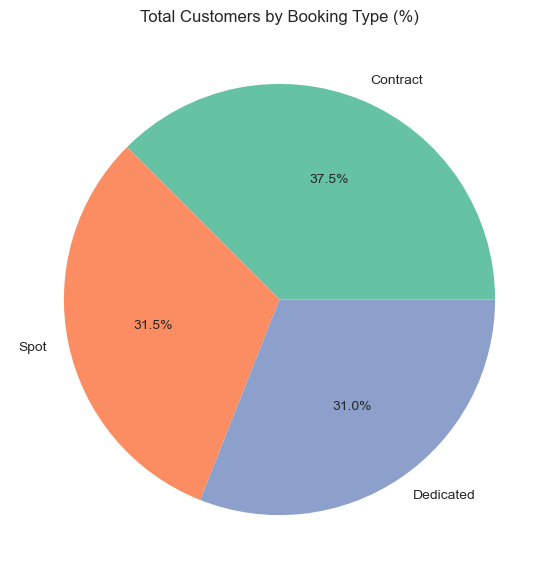

In [5]:
data = customers["customer_type"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
plt.pie(data, labels=data.index, autopct="%1.1f%%")
plt.title("Total Customers by Booking Type (%)")
plt.show()


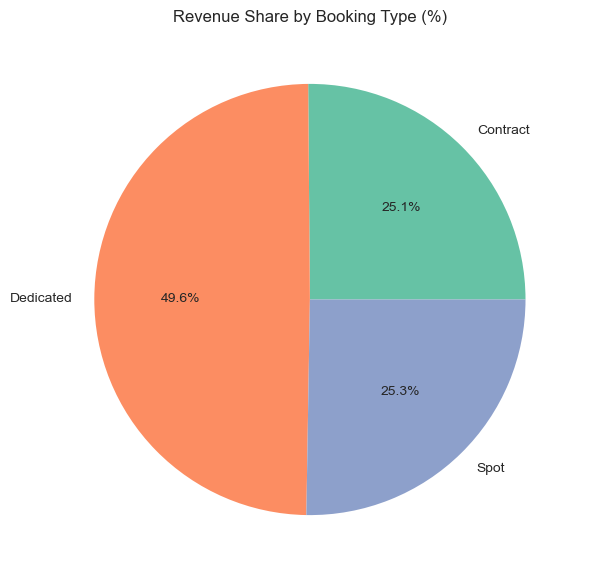

In [6]:
# Calculate revenue by booking type
data = loads.groupby("booking_type")["revenue"].sum()

# Convert to percentage
data = (data / data.sum()) * 100

# Plot
plt.figure(figsize=(7,7))
plt.pie(data, labels=data.index, autopct="%1.1f%%")
plt.title("Revenue Share by Booking Type (%)")
plt.show()



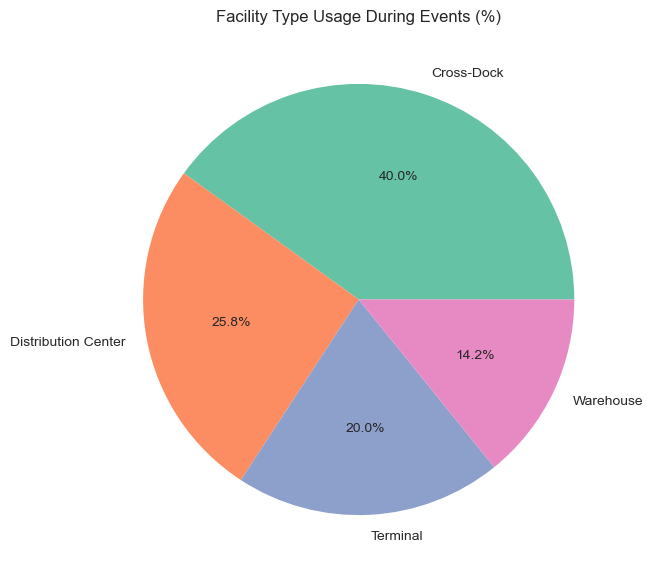

In [7]:
# Merge events with facilities
events_facilities = delivery_events.merge(facilities,on="facility_id",how="left")

# Count usage by facility type
data = events_facilities["facility_type"].value_counts(normalize=True) * 100

# Plot
plt.figure(figsize=(7,7))
plt.pie(data, labels=data.index, autopct="%1.1f%%")
plt.title("Facility Type Usage During Events (%)")
plt.show()


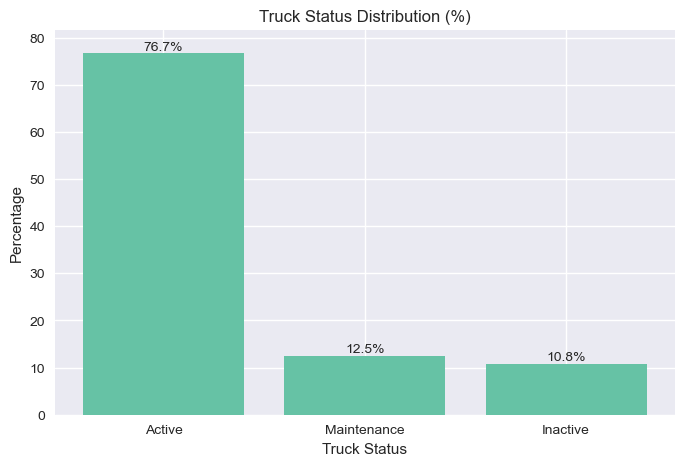

In [8]:
data = trucks["status"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
bars = plt.bar(data.index.astype(str), data.values)

plt.xlabel("Truck Status")
plt.ylabel("Percentage")
plt.title("Truck Status Distribution (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, data.max() + 5)
plt.show()


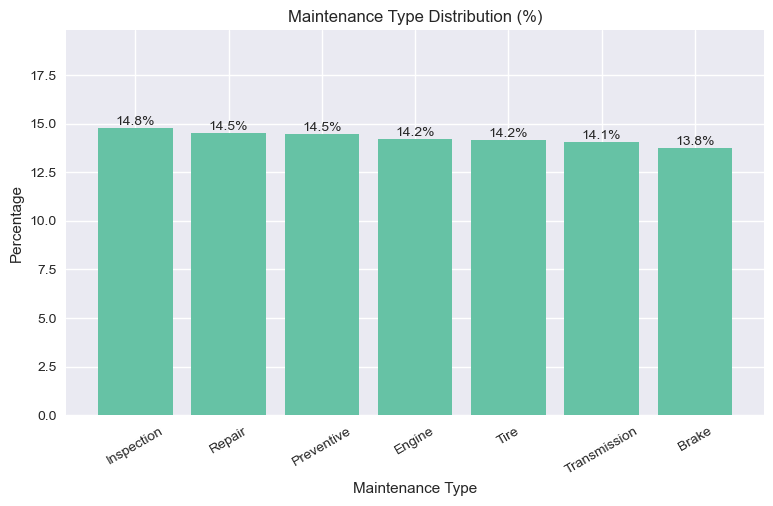

In [9]:
data = maintenance_records["maintenance_type"].value_counts(normalize=True) * 100

plt.figure(figsize=(9,5))
bars = plt.bar(data.index.astype(str), data.values)

plt.xlabel("Maintenance Type")
plt.ylabel("Percentage")
plt.title("Maintenance Type Distribution (%)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}%",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=30)
plt.ylim(0, data.max() + 5)
plt.show()


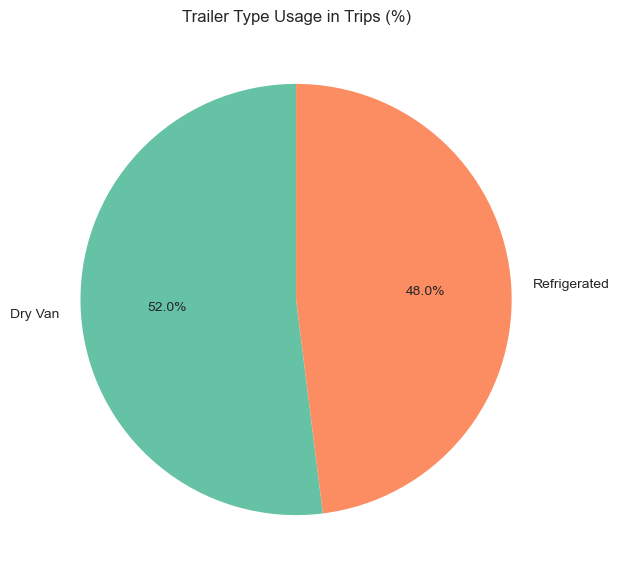

In [10]:
# Merge trips with trailers
trips_trailers = trips.merge(
    trailers[["trailer_id", "trailer_type"]],
    on="trailer_id",
    how="left"
)

# Count usage
data = trips_trailers["trailer_type"].value_counts(normalize=True) * 100

# Plot
plt.figure(figsize=(7,7))
plt.pie(
    data,
    labels=data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Trailer Type Usage in Trips (%)")
plt.show()



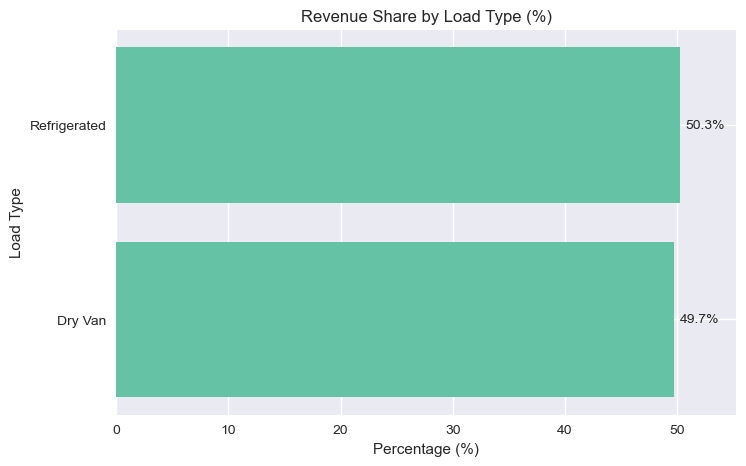

In [11]:
# Calculate revenue share %
revenue_share = loads.groupby("load_type")["revenue"].sum()
revenue_share = revenue_share / revenue_share.sum() * 100
revenue_share = revenue_share.sort_values()

# Plot
plt.figure(figsize=(8,5))
bars = plt.barh(revenue_share.index, revenue_share.values)

plt.title("Revenue Share by Load Type (%)")
plt.xlabel("Percentage (%)")
plt.ylabel("Load Type")

# Add percentage labels
for i, v in enumerate(revenue_share.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center')

plt.xlim(0, revenue_share.max() + 5)

plt.show()


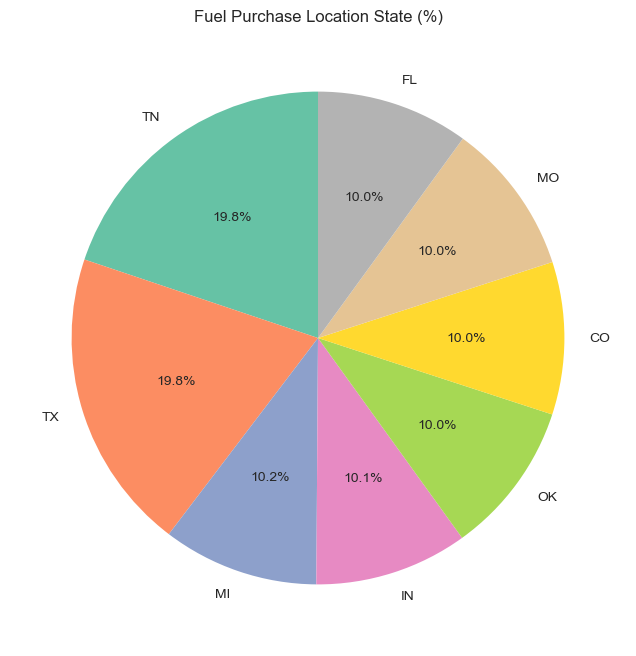

In [12]:
data = fuel_purchases["location_state"].value_counts(normalize=True).head(8) * 100

plt.figure(figsize=(8,8))
plt.pie(
    data,
    labels=data.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Fuel Purchase Location State (%)")
plt.show()


# DIAGNOSTIC ANALYSIS

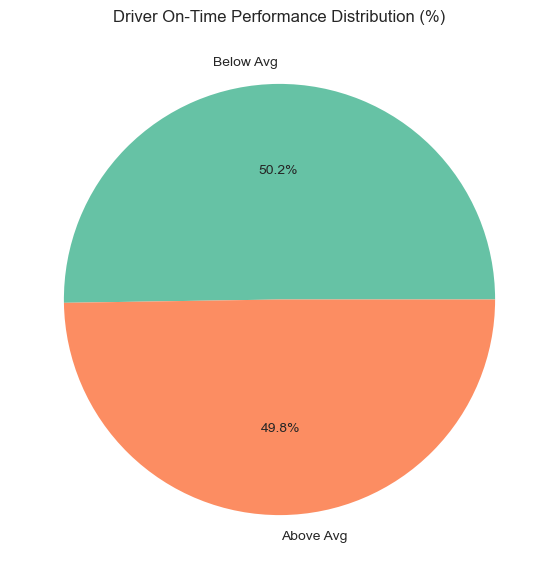

In [13]:
# Create flag
driver_monthly_metrics["low_otp"] = (
    driver_monthly_metrics["on_time_delivery_rate"]
    < driver_monthly_metrics["on_time_delivery_rate"].mean()
)

# Convert True/False to readable labels
driver_monthly_metrics["performance"] = driver_monthly_metrics["low_otp"].map({
    True: "Below Avg",
    False: "Above Avg"
})

# Calculate percentage
data = driver_monthly_metrics["performance"].value_counts(normalize=True) * 100

# Plot
plt.figure(figsize=(7,7))
plt.pie(data, labels=data.index, autopct="%1.1f%%")
plt.title("Driver On-Time Performance Distribution (%)")
plt.show()


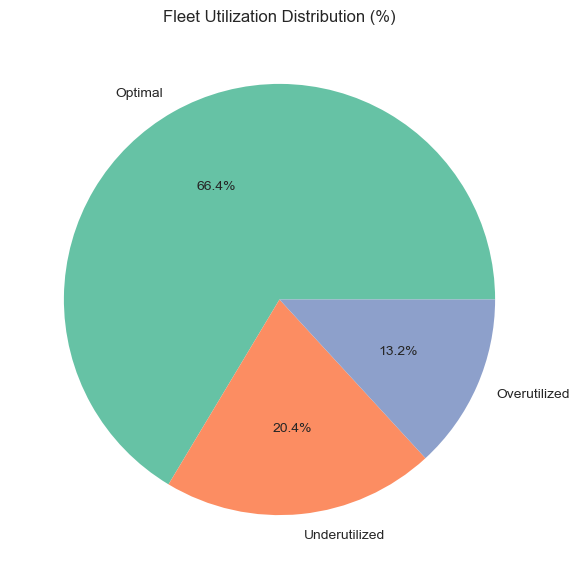

In [14]:
def categorize_util(x):
    if x < 0.7:
        return "Underutilized"
    elif x <= 1:
        return "Optimal"
    else:
        return "Overutilized"

truck_utilization_metrics["util_category"] = (
    truck_utilization_metrics["utilization_rate"]
    .apply(categorize_util)
)

data = (
    truck_utilization_metrics["util_category"]
    .value_counts(normalize=True) * 100
)

plt.figure(figsize=(7,7))
plt.pie(data, labels=data.index, autopct="%1.1f%%")
plt.title("Fleet Utilization Distribution (%)")
plt.show()


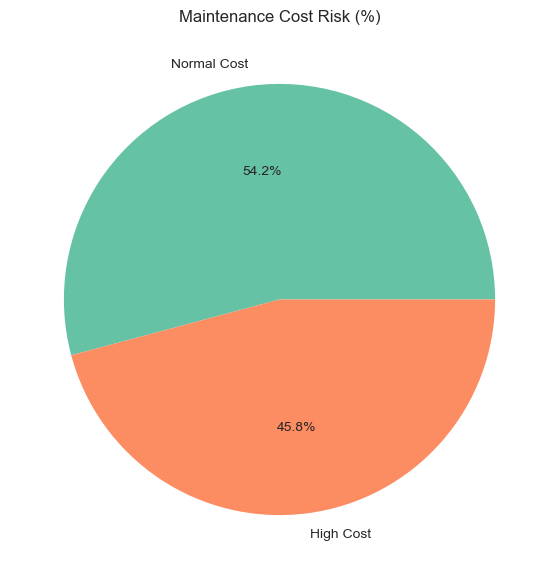

In [15]:
cost = maintenance_records.groupby("truck_id")["total_cost"].sum()
flag = cost > cost.mean()
data = flag.value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
plt.pie(data, labels=["Normal Cost","High Cost"], autopct="%1.1f%%")
plt.title("Maintenance Cost Risk (%)")
plt.show()


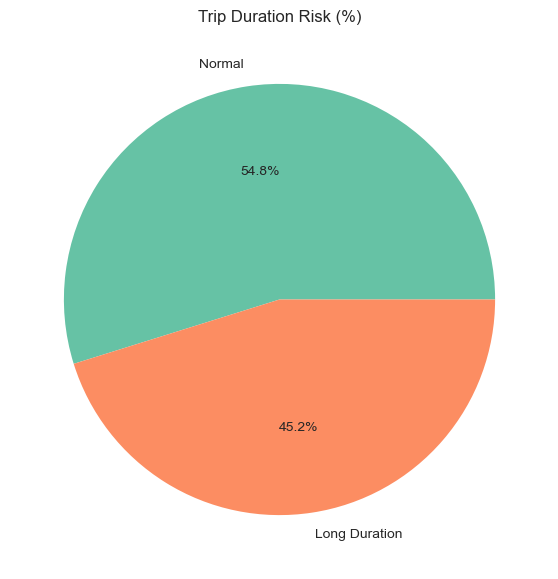

In [16]:
trips["long_trip"] = trips["actual_duration_hours"] > trips["actual_duration_hours"].mean()
data = trips["long_trip"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
plt.pie(data, labels=["Normal","Long Duration"], autopct="%1.1f%%")
plt.title("Trip Duration Risk (%)")
plt.show()


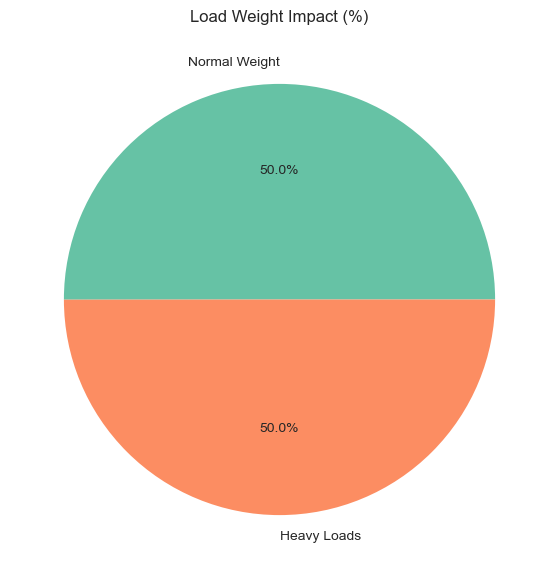

In [17]:
loads["heavy_load"] = loads["weight_lbs"] > loads["weight_lbs"].mean()
data = loads["heavy_load"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
plt.pie(data, labels=["Normal Weight","Heavy Loads"], autopct="%1.1f%%")
plt.title("Load Weight Impact (%)")
plt.show()


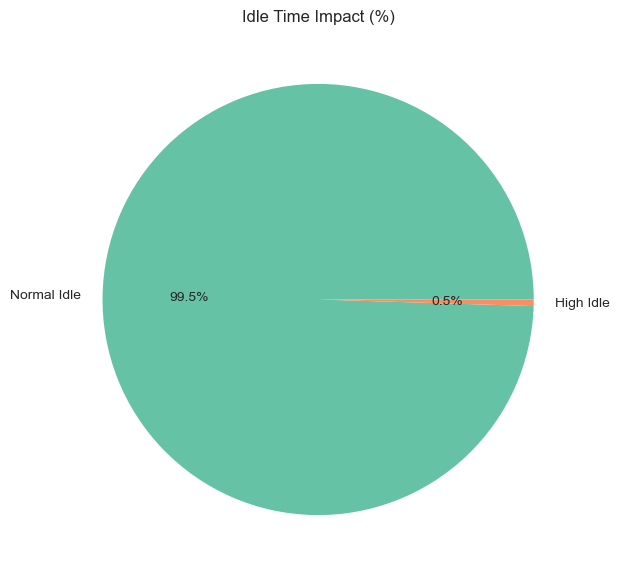

In [18]:
trips["high_idle"] = trips["idle_time_hours"] > 2
data = trips["high_idle"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
plt.pie(data, labels=["Normal Idle","High Idle"], autopct="%1.1f%%")
plt.title("Idle Time Impact (%)")
plt.show()


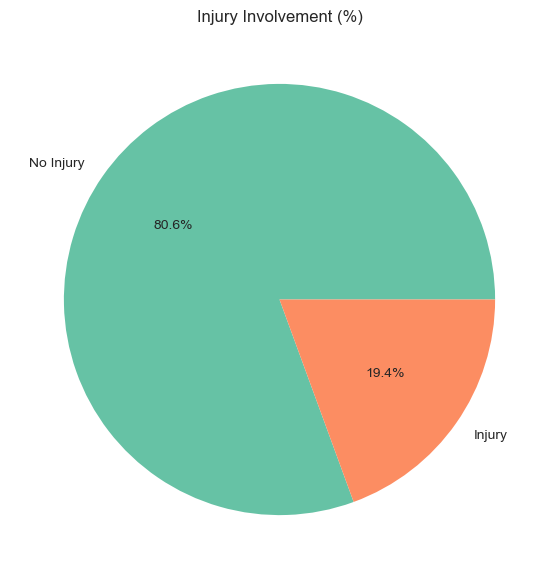

In [19]:
data = safety_incidents["injury_flag"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
plt.pie(data, labels=["No Injury","Injury"], autopct="%1.1f%%")
plt.title("Injury Involvement (%)")
plt.show()


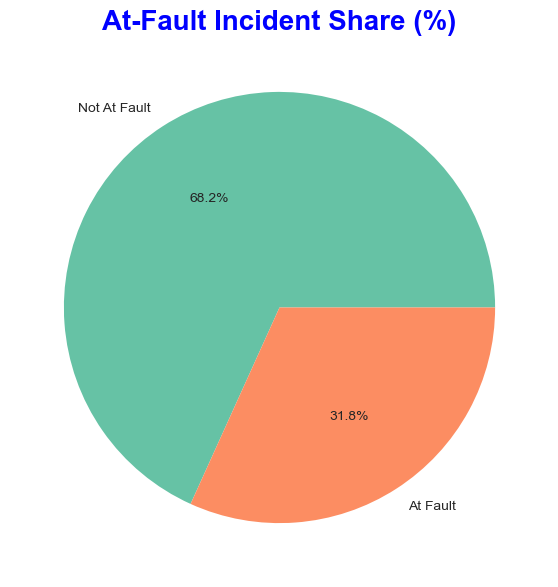

In [39]:
data = (
    safety_incidents["at_fault_flag"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

plt.figure(figsize=(7,7))
plt.pie(
    data,
    labels=["Not At Fault", "At Fault"],
    autopct="%1.1f%%"
)

plt.title("At-Fault Incident Share (%)",color='blue',fontsize=20,fontweight='bold')
plt.show()



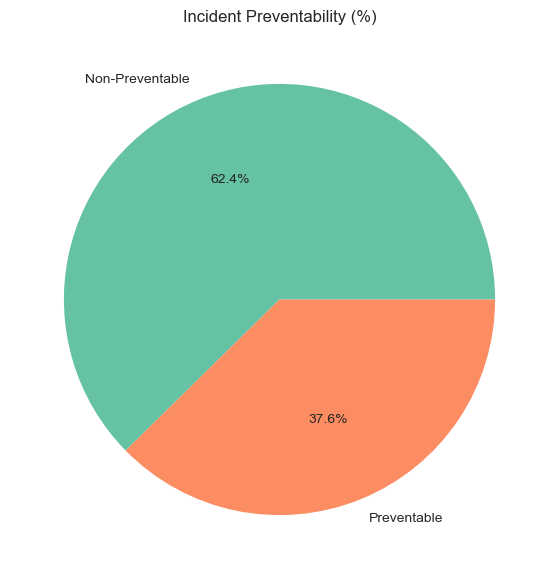

In [21]:
data = safety_incidents["preventable_flag"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
plt.pie(data, labels=["Non-Preventable","Preventable"], autopct="%1.1f%%")
plt.title("Incident Preventability (%)")
plt.show()


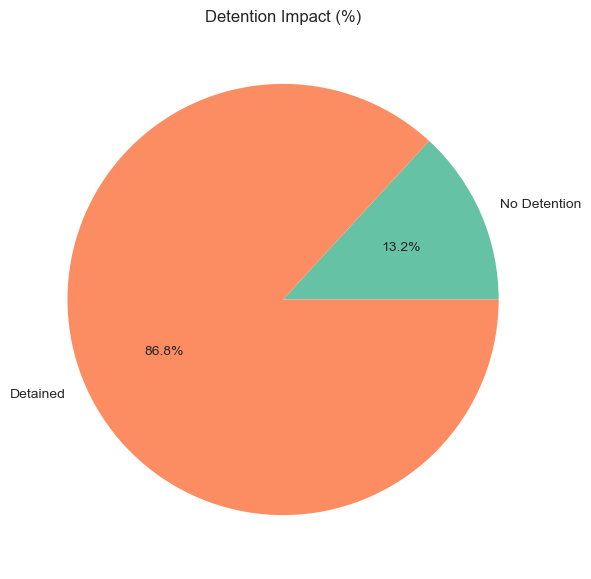

In [22]:
delivery_events["detained"] = delivery_events["detention_minutes"] > 0

data = delivery_events["detained"].value_counts(normalize=True).sort_index() * 100

plt.figure(figsize=(7,7))
plt.pie(data, labels=["No Detention","Detained"], autopct="%1.1f%%")
plt.title("Detention Impact (%)")
plt.show()



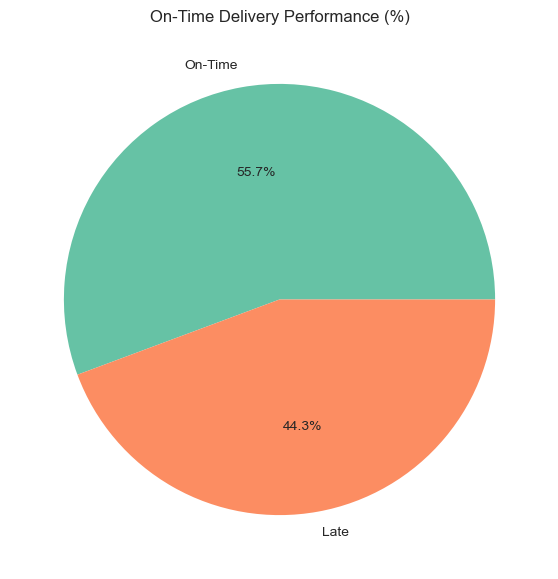

on_time_flag
True     55.669711
False    44.330289
Name: proportion, dtype: float64

In [23]:
data = delivery_events["on_time_flag"].value_counts(normalize=True) * 100

plt.figure(figsize=(7,7))
plt.pie(data, labels=["On-Time","Late"], autopct="%1.1f%%")
plt.title("On-Time Delivery Performance (%)")
plt.show()
data

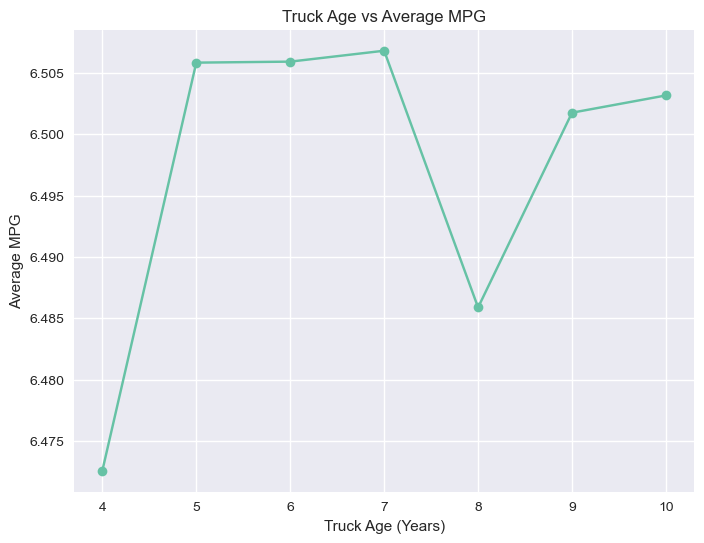

In [24]:
# Merge trips with trucks
merged = trips.merge(trucks, on="truck_id")

# Calculate truck age
merged["truck_age"] = 2025 - merged["model_year"]

# Group by truck age
age_mpg = merged.groupby("truck_age")["average_mpg"].mean()

# Plot
plt.figure(figsize=(8,6))
plt.plot(age_mpg.index, age_mpg.values, marker="o")

plt.title("Truck Age vs Average MPG")
plt.xlabel("Truck Age (Years)")
plt.ylabel("Average MPG")
plt.grid(True)
plt.show()


In [25]:
delivery_events["detained"] = delivery_events["detention_minutes"] > 0
data = delivery_events["detained"].value_counts(normalize=True) * 100

In [26]:
delivery_events.detained.value_counts()

detained
True     148348
False     22472
Name: count, dtype: int64

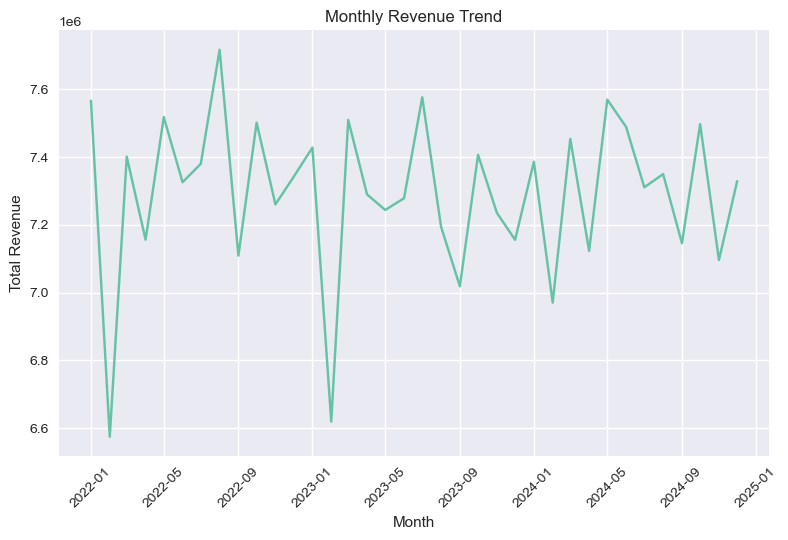

In [27]:
# Convert load_date to datetime
loads['load_date'] = pd.to_datetime(loads['load_date'])

# Create month column
loads['month'] = loads['load_date'].dt.to_period('M')

# Group by month and sum revenue
monthly_revenue = loads.groupby('month')['revenue'].sum().reset_index()

# Convert month to timestamp for plotting
monthly_revenue['month'] = monthly_revenue['month'].dt.to_timestamp()

# Plot monthly revenue trend
plt.figure()
plt.plot(monthly_revenue['month'], monthly_revenue['revenue'])
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


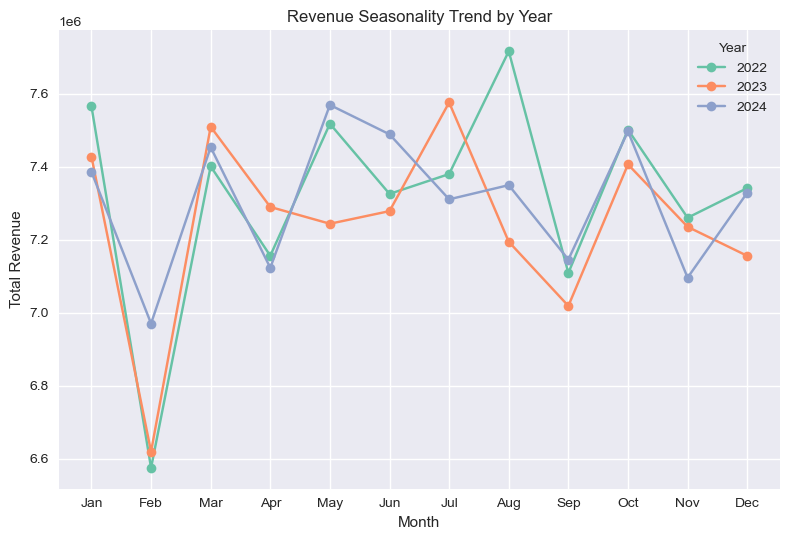

In [28]:

# Convert to datetime
loads['load_date'] = pd.to_datetime(loads['load_date'])

# Extract year and month name
loads['Year'] = loads['load_date'].dt.year
loads['Month'] = loads['load_date'].dt.month
loads['Month_Name'] = loads['load_date'].dt.strftime('%b')

# Group by Year and Month
monthly_revenue = loads.groupby(['Year', 'Month', 'Month_Name'])['revenue'].sum().reset_index()

# Sort properly by month number
monthly_revenue = monthly_revenue.sort_values(['Year', 'Month'])

# Plot seasonality (each year separate line)
plt.figure()

for year in monthly_revenue['Year'].unique():
    data = monthly_revenue[monthly_revenue['Year'] == year]
    plt.plot(data['Month'], data['revenue'], marker='o', label=str(year))

# Proper month labels
plt.xticks(
    ticks=range(1,13),
    labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
)

plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Revenue Seasonality Trend by Year")
plt.legend(title="Year")
plt.grid(True)
plt.tight_layout()
plt.show()


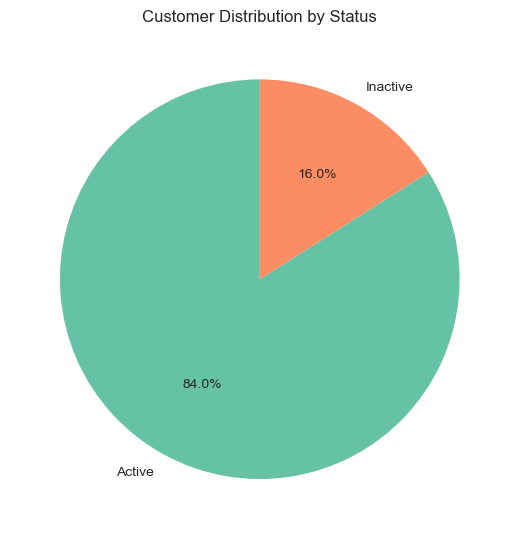

In [29]:
# Count customers by status
customer_status_count = customers['account_status'].value_counts()

# Plot pie chart
plt.figure()
plt.pie(
    customer_status_count,
    labels=customer_status_count.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Customer Distribution by Status")
plt.tight_layout()
plt.show()



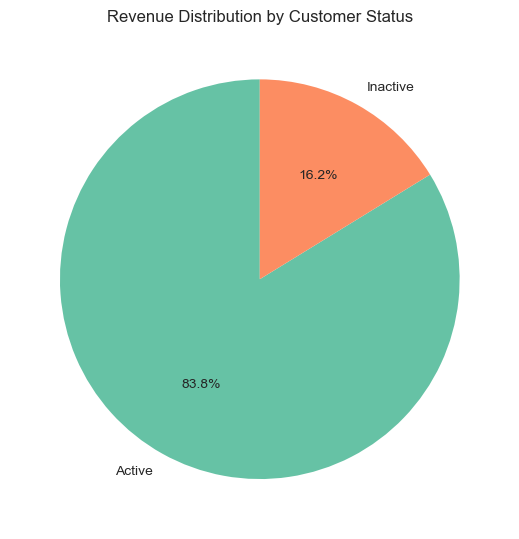

In [30]:
import matplotlib.pyplot as plt

# Merge loads with customers
load_customer = loads.merge(customers, on='customer_id', how='left')

# Revenue by status
revenue_by_status = load_customer.groupby('account_status')['revenue'].sum()

# Plot pie chart
plt.figure()
plt.pie(
    revenue_by_status,
    labels=revenue_by_status.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Revenue Distribution by Customer Status")
plt.tight_layout()
plt.show()


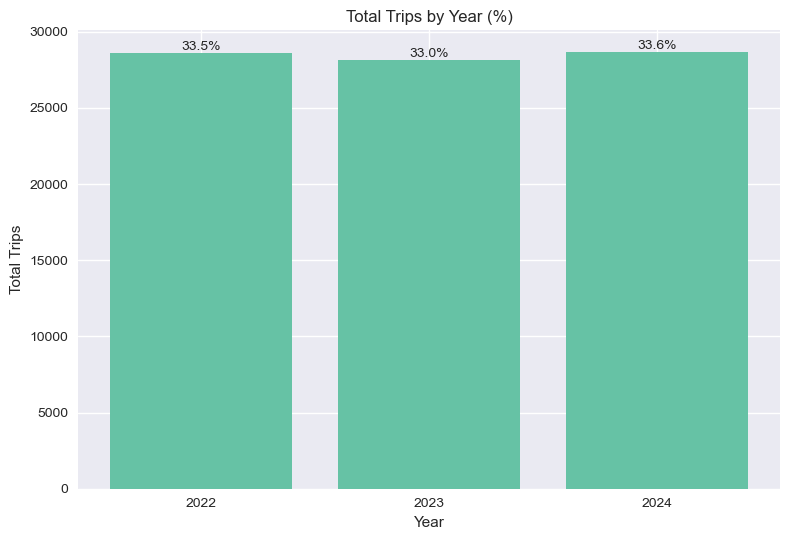

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert dispatch_date to datetime
trips['dispatch_date'] = pd.to_datetime(trips['dispatch_date'])

# Extract year
trips['Year'] = trips['dispatch_date'].dt.year

# Count trips per year
trips_by_year = trips.groupby('Year')['trip_id'].count().reset_index()
trips_by_year.columns = ['Year', 'Total_Trips']

# Calculate percentage contribution
total_trips = trips_by_year['Total_Trips'].sum()
trips_by_year['Percentage'] = (trips_by_year['Total_Trips'] / total_trips) * 100

# Plot
plt.figure()
bars = plt.bar(trips_by_year['Year'], trips_by_year['Total_Trips'])

# Add percentage labels
for bar, pct in zip(bars, trips_by_year['Percentage']):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{pct:.1f}%',
        ha='center',
        va='bottom'
    )

plt.xlabel("Year")
plt.ylabel("Total Trips")
plt.title("Total Trips by Year (%)")
plt.xticks(trips_by_year['Year'])
plt.tight_layout()
plt.show()


In [32]:

total_idle_hours = trips['idle_time_hours'].sum()
total_trip_hours = trips['actual_duration_hours'].sum()

idle_percentage = (total_idle_hours / total_trip_hours) * 100
idle_percentage

28.026682664145664

In [33]:
total_incidents = safety_incidents['incident_id'].count()
total_miles = trips['actual_distance_miles'].sum()

incident_rate_per_100k = (total_incidents / total_miles) * 100000
incident_rate_per_100k

0.13916266528298593

In [34]:
safety_incidents['incident_total_cost'] = (
    safety_incidents['vehicle_damage_cost'] +
    safety_incidents['cargo_damage_cost'] +
    safety_incidents['claim_amount']
)

total_incident_cost = safety_incidents['incident_total_cost'].sum()

incident_cost_per_mile = total_incident_cost / total_miles


In [35]:
incident_cost_per_mile

0.04343793669704831

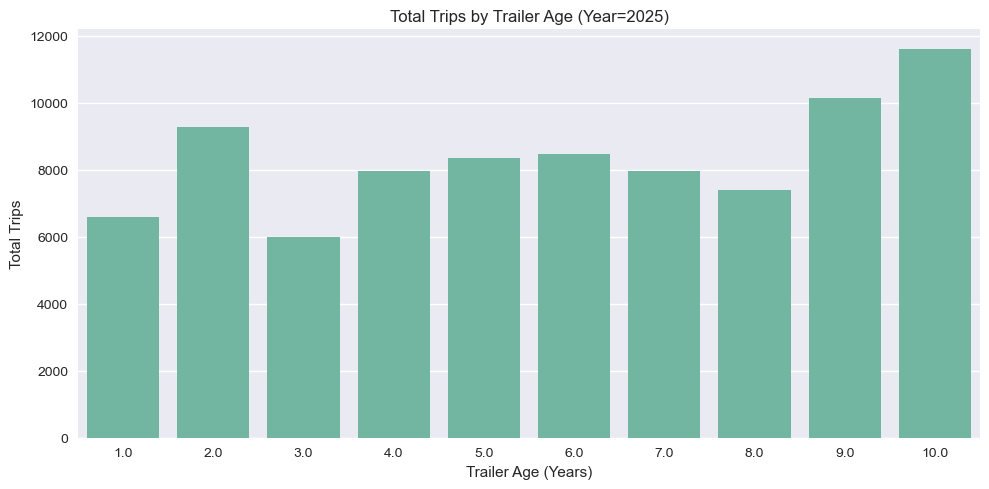

C:\Users\Administrator\AppData\Local\Temp\ipykernel_1516\3122550704.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_group')['trip_id']


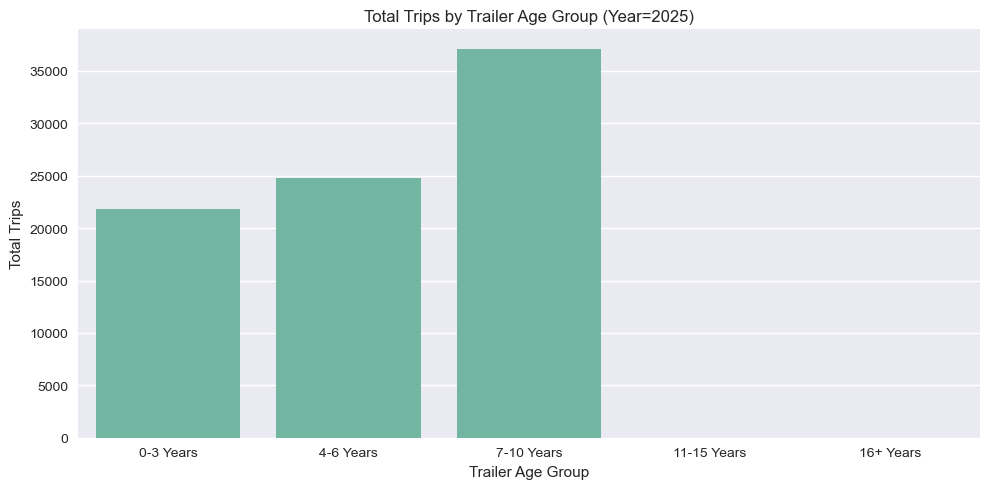

C:\Users\Administrator\AppData\Local\Temp\ipykernel_1516\2662844941.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('age_group')['trip_id']


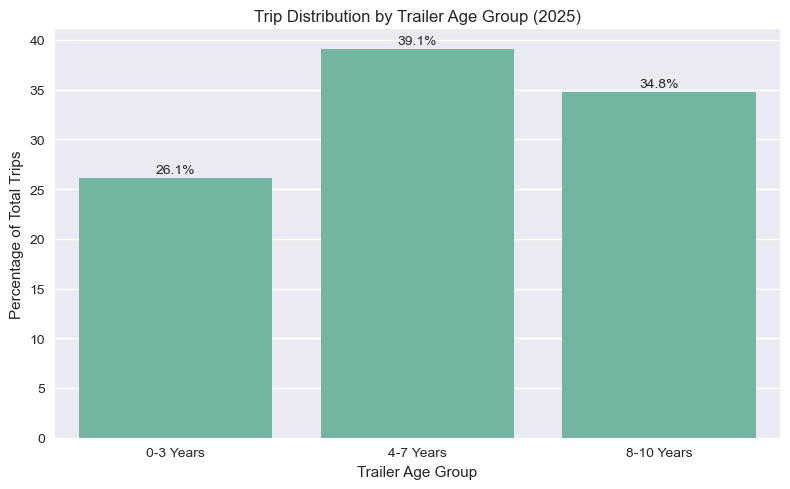

In [43]:
CURRENT_YEAR = 2025

# ------------------------------
# 1️⃣ TOTAL TRIPS BY TRAILER AGE (%)
# ------------------------------

# Calculate trailer age
trailers['trailer_age'] = CURRENT_YEAR - trailers['model_year']

# Keep only trailers <= 10 years
trailers = trailers[trailers['trailer_age'] <= 10]

# Create 3 bins
bins = [0, 3, 7, 10]
labels = ['0-3 Years', '4-7 Years', '8-10 Years']

trailers['age_group'] = pd.cut(
    trailers['trailer_age'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Merge
trips_trailers = trips.merge(
    trailers[['trailer_id', 'age_group']],
    on='trailer_id',
    how='inner'
)

# Aggregate
trips_by_age = (
    trips_trailers
    .groupby('age_group')['trip_id']
    .count()
    .reset_index(name='total_trips')
)

# Convert to percentage
trips_by_age['percentage'] = (
    trips_by_age['total_trips'] /
    trips_by_age['total_trips'].sum()
) * 100

# Plot
plt.figure(figsize=(8,5))
ax = sns.barplot(data=trips_by_age, x='age_group', y='percentage')

plt.title("Trip Distribution by Trailer Age Group ")
plt.xlabel("Trailer Age Group")
plt.ylabel("Percentage of Total Trips")

# Add % labels
for i, row in trips_by_age.iterrows():
    ax.text(i, row['percentage'] + 0.5,
            f"{row['percentage']:.1f}%",
            ha='center')

plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_1516\974234682.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


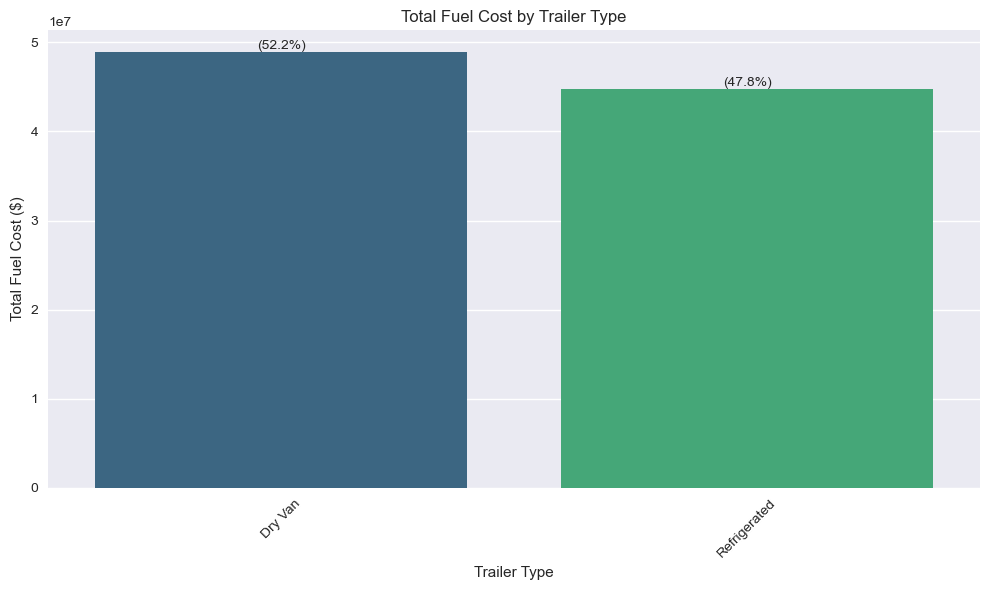

In [48]:
fuel_trips = fuel_purchases.merge(
    trips[['trip_id', 'trailer_id']],
    on='trip_id',
    how='left'
)

fuel_full = fuel_trips.merge(
    trailers[['trailer_id', 'trailer_type']],
    on='trailer_id',
    how='left'
)

# ------------------------------
# AGGREGATE TOTAL FUEL COST BY TRAILER TYPE
# ------------------------------

fuel_by_type = (
    fuel_full
    .groupby('trailer_type')['total_cost']
    .sum()
    .reset_index()
    .sort_values('total_cost', ascending=False)
)

# Calculate percentage contribution
fuel_by_type['percentage'] = (
    fuel_by_type['total_cost'] /
    fuel_by_type['total_cost'].sum()
) * 100

# ------------------------------
# PLOT CHART
# ------------------------------

plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=fuel_by_type,
    x='trailer_type',
    y='total_cost',
    palette="viridis"
)

plt.title("Total Fuel Cost by Trailer Type")
plt.xlabel("Trailer Type")
plt.ylabel("Total Fuel Cost ($)")
plt.xticks(rotation=45)

# Add data labels: $ and %
for i, row in fuel_by_type.iterrows():
    ax.text(
        i,
        row['total_cost'],
        f"({row['percentage']:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

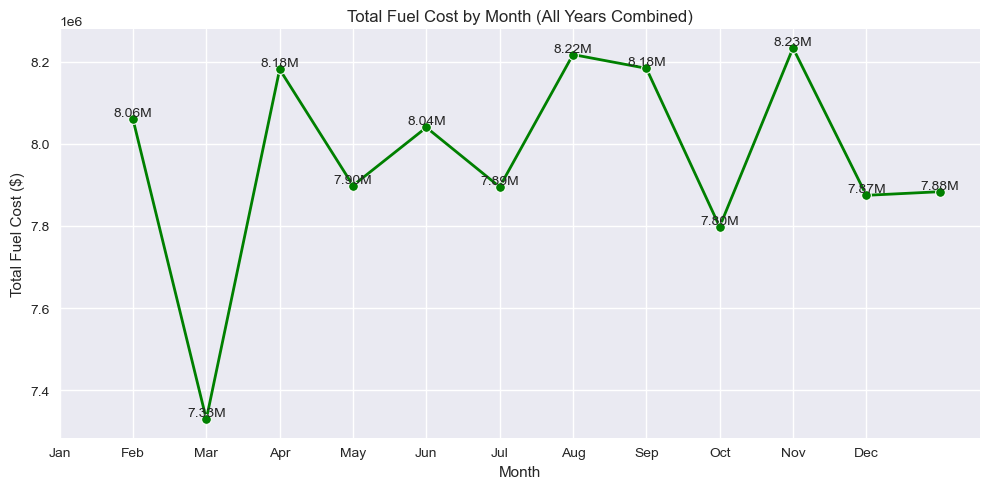

In [54]:
fuel_purchases['purchase_date'] = pd.to_datetime(fuel_purchases['purchase_date'])

# ------------------------------
# EXTRACT MONTH NUMBER
# ------------------------------
fuel_purchases['month'] = fuel_purchases['purchase_date'].dt.month

# ------------------------------
# AGGREGATE TOTAL FUEL COST PER MONTH
# ------------------------------
monthly_fuel = (
    fuel_purchases
    .groupby('month')['total_cost']
    .sum()
    .reset_index()
    .sort_values('month')
)

# ------------------------------
# PLOT LINE CHART
# ------------------------------
plt.figure(figsize=(10,5))
ax = sns.lineplot(
    data=monthly_fuel,
    x='month',
    y='total_cost',
    marker='o',
    color='green',
    linewidth=2
)

plt.title("Total Fuel Cost by Month (All Years Combined)")
plt.xlabel("Month")
plt.ylabel("Total Fuel Cost ($)")
plt.xticks(ticks=range(0,12), labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

# ------------------------------
# ADD DATA LABELS IN MILLIONS
# ------------------------------
for i, row in monthly_fuel.iterrows():
    cost_m = row['total_cost'] / 1_000_000
    ax.text(
        row['month'],  # index starts at 0 for labels
        row['total_cost'],
        f"{cost_m:.2f}M",
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()